In [1]:
# This script reads from MetUM archive (*.pp) files in a specified 
# directory (inputdir) to interpolate a field (potential temperature) 
# to a specified isobaric level (700 hPa).

# import libraries
import glob
import iris
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# specify the directory containing the MetUM archive files
inputdir='/gws/ssde/j25b/team_x/users/kahern/hackathon/metum/20250629T1200Z'

In [3]:
# use pattern matching to find any MetUM archives
# in the specified input directory. 
allfiles = glob.glob(f"{inputdir}/*.pp")
allfiles.sort()

In [4]:
# Our goal is to interpolate data from model levels
# to a specified isobaric level. First, we will need
# pressure data on model levels, but pressure data
# are not available on model levels for these simulations.
# We can use potential temperature and air temperature
# to calculate pressure.
# let's get the cubes containing potential temperature and
# air temperature data.

# Load the cube with potential temperature data.
# First, specify a name constraint so we can load
# just the cube(s) with potential temperature.
# Let's also specify that we only want the data from forecast hour 24.
# Then use those constraints to load the data.
fcsthr = 24.
cond = iris.Constraint(name="air_potential_temperature", forecast_period=fcsthr)
cubes = iris.load(allfiles, constraints=cond)
theta = cubes[0].data

/home/users/kahern/conda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [5]:
# Next, load the air temperature:
cond = iris.Constraint(name="air_temperature", forecast_period=fcsthr)
cubes = iris.load(allfiles, constraints=cond)
tk = cubes[0].data

In [6]:
# calculate pressure on model levels:
prs = 100000.0 * pow(tk / theta, 1005.0 / 287.0)

In [7]:
# Now we need some model data to interpolate to an isobaric level.
# We already have potential temperature, so we can use that. 
# We could interpolate to multiple levels, but for now, 
# let's linearly interpolate the data to 700 hPa only.

targp = [700.0]

# z-indices and weights to do interpolations
ku = np.zeros((len(targp),prs.shape[1],prs.shape[2]),dtype=int)
kl = np.zeros((len(targp),prs.shape[1],prs.shape[2]),dtype=int)
wu = np.empty((len(targp),prs.shape[1],prs.shape[2]))
wl = np.empty((len(targp),prs.shape[1],prs.shape[2]))

for k in range(len(targp)):
    tp = targp[k] * 100.0
    # get the diffs between pressures at each level and the target pressure
    dp = tp - prs
    
    # maskout all data where dp is negative
    posmask = (dp < 0)
    posdp = np.ma.masked_array(dp, mask=posmask)
    negmask = (dp > 0)        
    negdp = np.ma.masked_array(dp, mask=negmask)
    
    # get an array of the z-indices where non-negative dp is smallest
    posidx = np.nanargmin(posdp, axis=0)
    negidx = np.nanargmax(negdp, axis=0)

    for j in range(posidx.shape[0]):
        for i in range(posidx.shape[1]):
            pu = prs[posidx[j,i],j,i]
            pl = prs[negidx[j,i],j,i]
            if pu <= tp and pl >= tp:
                ku[k,j,i] = posidx[j,i]
                kl[k,j,i] = negidx[j,i]
                interdp = dp[ku[k,j,i],j,i] - dp[kl[k,j,i],j,i]
                wu[k,j,i] = 1.0 - (dp[ku[k,j,i],j,i] / interdp)
                wl[k,j,i] = 1.0 - (-dp[kl[k,j,i],j,i] / interdp)
            else:
                ku[k,j,i] = -1
                kl[k,j,i] = -1
                wu[k,j,i] = np.nan
                wl[k,j,i] = np.nan

In [8]:
# Now that we have the weights for interpolation, 
# we can interpolate potential temperature to 700 hPa.
# Let's make a function that will take in a model field
# and return the field interpolated to 700 hPa.
def interp2prs(field):
    if field.ndim != 3:
        print(f"error: field passed needs 3 dims ({field.ndim})")
        return field
    if field.shape[0] != prs.shape[0]:
        print(f"error: field passed has inconsistent z-dim ({field.shape[0]} != {prs.shape[0]})")
        return field
    if field.shape[1] != prs.shape[1]:
        print(f"error: field passed has inconsistent y-dim ({field.shape[1]} != {prs.shape[1]})")
        return field
    if field.shape[2] != prs.shape[2]:
        print(f"error: field passed has inconsistent x-dim ({field.shape[2]} != {prs.shape[2]})")
        return field
    
    rarr = np.empty(ku.shape)
    for k in range(rarr.shape[0]):
        for j in range(rarr.shape[1]):
            for i in range(rarr.shape[2]):
                if ku[k,j,i] < 0:
                    rarr[k,j,i] = np.nan
                else:
                    rarr[k,j,i] = (wu[k,j,i] * field[ku[k,j,i],j,i]) \
                        + (wl[k,j,i] * field[kl[k,j,i],j,i])
        
    return rarr

In [9]:
# Call the interpolation function
itheta = interp2prs(theta)

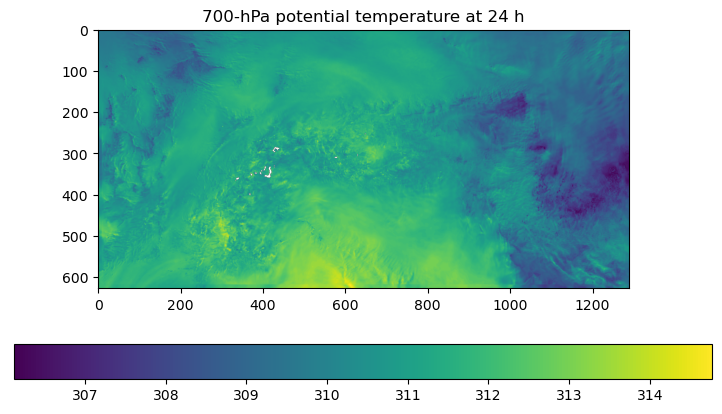

In [10]:
# let's try to plot the 700-hPa potential temperature
fig = plt.figure(figsize=(9, 4.8))

ax = fig.add_subplot()
ax.set_title(f"700-hPa potential temperature at {int(fcsthr)} h")
plt.imshow(itheta[0,::-1,:]) # <-- uninvert data along y-axis
ax.set_aspect('equal')

cax = fig.add_axes([0.12, 0.1, 0.78, 0.8])
cax.get_xaxis().set_visible(False)
cax.get_yaxis().set_visible(False)
cax.patch.set_alpha(0)
cax.set_frame_on(False)
plt.colorbar(orientation='horizontal')
plt.show()